In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model, decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.formula.api as smf

In [4]:
A=pd.read_csv('kc_house_data.csv')
A.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


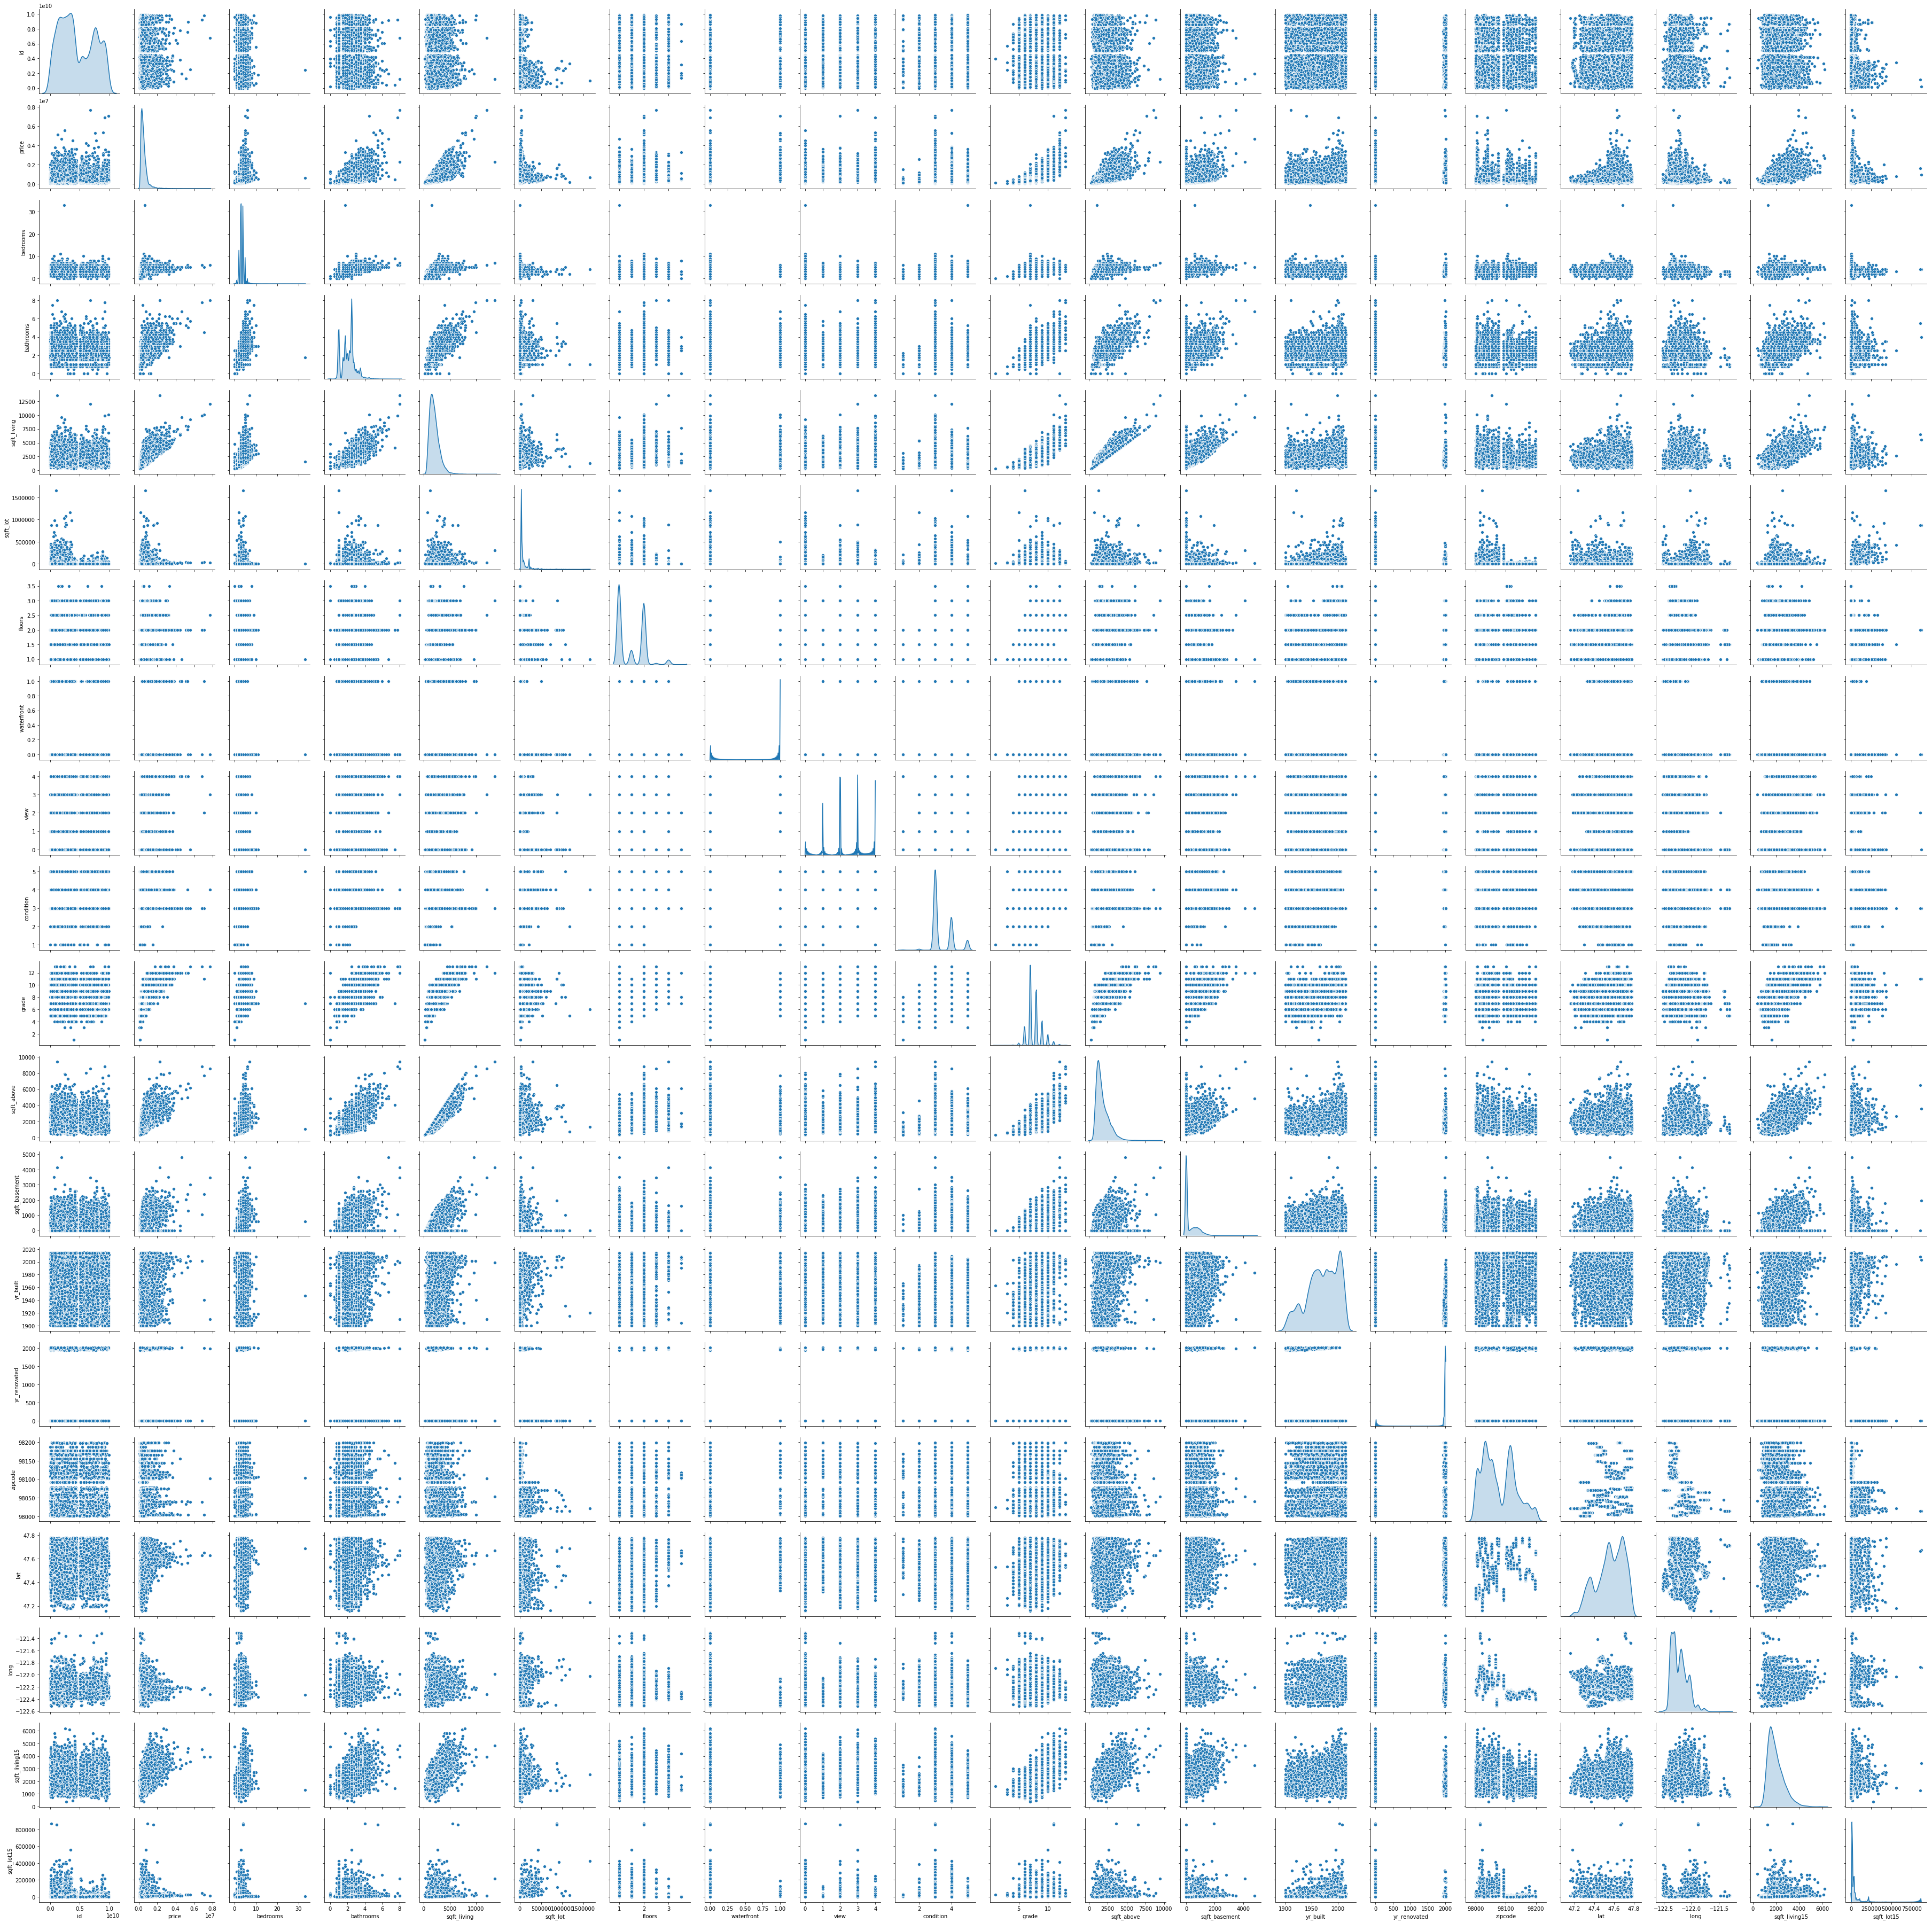

In [5]:
asns.pairplot(A,diag_kind='kde')

In [6]:
A.corr()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


In [7]:
A.shape

(21613, 21)

m1=smf.ols('id+date+price+bedrooms+bathrooms+sqft_living+sqft_lot+floors+waterfront+view+condition+grade+sqft_above+sqft_basement+yr_built+yr_renovated+zipcode+lat+long+sqft_living15+lotSize area in 2015',A).fit()

In [82]:
X=A.drop(['zipcode', 'lat', 'long', 'id', 'date', 'yr_renovated'],axis=1)
Y=A[['price']]

In [36]:
no_loc_df=A.drop(['zipcode', 'lat', 'long', 'id', 'date', 'yr_renovated'], axis=1).fillna(0)
no_loc_df=no_loc_df[no_loc_df.apply(lambda x: np.abs(x-x.mean())/float(x.std())< 3, axis=0).all(axis=1)]
no_loc_df['ones']=np.ones(no_loc_df.shape[0])
# no_loc_df.date=pd.to_datetime(no_loc_df.date)
price=no_loc_df.pop('price')

In [53]:
from sklearn.model_selection import cross_val_score


lr=LinearRegression()
X=StandardScaler().fit_transform(no_loc_df)
X_train,X_test,y_train, y_test= train_test_split(X,price)
X_train,X_test,y_train, y_test= train_test_split(X,price)
scores=cross_val_score(lr,X_train,y_train, cv=5)
np.mean(scores)

C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


0.5872118056994344

In [54]:
lr.fit(X_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [55]:
lr.score(X_test,y_test)

0.5678701823124301

In [48]:
c=np.arange(len(lr.coef_))

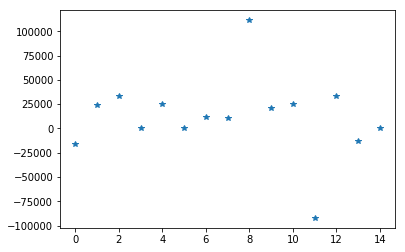

In [49]:
plt.plot(c,lr.coef_,'*')

In [50]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [56]:
rd=Ridge(alpha=0.5,normalize=True)
Ls=Lasso(alpha=0.05,normalize=True)

In [72]:
rd.fit(Xtrain,ytrain)
rd_pred=rd.predict(Xtest)
Ls.fit(Xtrain,ytrain)
Ls_pred=Ls.predict(Xtest)

In [73]:
from sklearn.metrics import mean_squared_error
rd_rmse=np.sqrt(mean_squared_error(ytest,rd_pred))
rd_rmse

127884.73685553328

In [74]:
rd.coef_

array([[ 4.81630487e-01, -3.75043660e+03,  1.95104631e+04,
         3.36164218e+01, -8.02280745e-03,  1.36727126e+04,
         2.19185266e+05,  2.47764282e+04,  1.06429334e+04,
         3.40803098e+04,  3.05381171e+01,  3.62299509e+01,
        -8.82481006e+02,  2.77623457e+01, -1.15908929e-01]])

In [76]:
Ls_rmse=np.sqrt(mean_squared_error(ytest,Ls_pred))
Ls_rmse

6.856077843161633

In [83]:
variables=X.columns

In [84]:
Ls.coef_

array([0.99998265, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

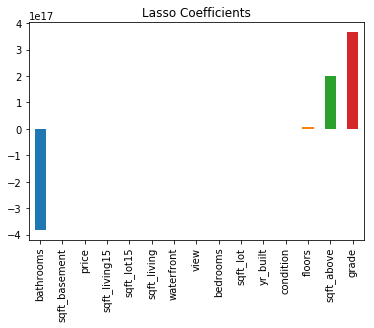

In [90]:
lasso_beta=pd.Series(lr.coef_,variables).sort_values()
lasso_beta.plot(kind='bar',title='Lasso Coefficients')

In [95]:
from sklearn import metrics
from sklearn.model_selection import KFold
LR=LinearRegression(normalize=True)
Ridge_R=Ridge(alpha=0.5,normalize=True)
Lasso_R=Lasso(alpha=0.1,normalize=True)

In [96]:
kf=KFold(n_splits=3,shuffle=True,random_state=2)
for model, name in zip([LR,Ridge_R,Lasso_R],['MVLR','Ridge','Lasso']):
    rmse=[]
    for train,test in kf.split(X,Y):
        Xtrain,Xtest=X.iloc[train,:],X.iloc[test,:]
        Ytrain,Ytest=Y.iloc[train],Y.iloc[test]
        model.fit(Xtrain,Ytrain)
        Y_predict=model.predict(Xtest)
        rmse.append(np.sqrt(metrics.mean_squared_error(Ytest,Y_predict)))
    print(rmse)
    print("Cross_Validated_rmse_score: %0.03f (+/- %0.5f) [%s]" % (np.mean(rmse),np.var(rmse,ddof=1),name))   

[5.375167813840107e-10, 1.1008570238850318e-09, 1.2584619262519664e-09]
Cross_Validated_rmse_score: 0.000 (+/- 0.00000) [MVLR]
[117832.33990264623, 117213.06411041938, 119012.33714198273]
Cross_Validated_rmse_score: 118019.247 (+/- 835546.57230) [Ridge]
[12.185463480011732, 11.719402575713655, 12.108546178413528]
Cross_Validated_rmse_score: 12.004 (+/- 0.06243) [Lasso]
